# Notebook 3 — Interpretabilidad con LIME

## 1. Importación de librerías

In [5]:
import warnings, joblib, os
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from lime.lime_tabular import LimeTabularExplainer

# Cambiar al directorio raíz del proyecto
if os.getcwd().endswith('Notebooks'):
    os.chdir('..')

## 2. Carga del modelo y datos

In [6]:
# Cargar el mejor modelo exportado por el Notebook 2
model = joblib.load('app/model.joblib')

# Cargar los splits del Notebook 1
X_train, X_test, y_train, y_test = joblib.load('data/train_test_splits.joblib')
feature_lists = joblib.load('data/feature_lists.joblib')

numerical_features_all = feature_lists['numerical']
categorical_features   = feature_lists['categorical']
all_feature_names      = feature_lists['all_encoded']

print(f'Modelo cargado: {type(model.named_steps["clf"]).__name__}')
print(f'X_train shape: {X_train.shape}')
print(f'X_test  shape: {X_test.shape}')
print(f'Features originales: {X_train.shape[1]}')
print(f'Features tras OHE:   {len(all_feature_names)}')

Modelo cargado: CatBoostClassifier
X_train shape: (5634, 19)
X_test  shape: (1409, 19)
Features originales: 19
Features tras OHE:   30


## 3. Configuración del LimeTabularExplainer

In [7]:
from sklearn.preprocessing import LabelEncoder

# Índices de las columnas categóricas en el DataFrame original
all_columns = list(X_train.columns)
cat_indices = [all_columns.index(c) for c in categorical_features]

# Preparamos los datos codificándolos como enteros para LIME
X_train_encoded = X_train.copy()
X_test_encoded  = X_test.copy()
categorical_names_dict = {}

for c in categorical_features:
    le = LabelEncoder()
    # Entrenar y transformar a enteros
    X_train_encoded[c] = le.fit_transform(X_train[c].astype(str))
    X_test_encoded[c]  = le.transform(X_test[c].astype(str))
    
    # Guardar este mapeo (ej. 0: 'Female', 1: 'Male') para que LIME lo sepa
    idx = all_columns.index(c)
    categorical_names_dict[idx] = le.classes_.tolist()

# LIME trabaja con arrays numéricos (enteros y flotantes)
X_train_arr = X_train_encoded.values
X_test_arr  = X_test_encoded.values

explainer = LimeTabularExplainer(
    training_data         = X_train_arr,
    feature_names         = all_columns,
    class_names           = ['No Churn', 'Churn'],
    categorical_features  = cat_indices,
    categorical_names     = categorical_names_dict,
    mode                  = 'classification',
    discretize_continuous = True,
    random_state          = 42
)

print(f'Total de features originales: {len(all_columns)}')

Total de features originales: 19


## 4. Selección de casos representativos

Se seleccionan tres instancias del conjunto de prueba que representen escenarios distintos:
- **Caso 1 — Alto riesgo:** probabilidad de churn > 0.80
- **Caso 2 — Bajo riesgo:** probabilidad de churn < 0.15
- **Caso 3 — Ambiguo:** probabilidad cercana a 0.50 (zona de incertidumbre del modelo)

In [8]:
# Obtener probabilidades de churn para todo el test set
probs = model.predict_proba(X_test)[:, 1]

# Seleccionar índices representativos
# Alto riesgo: mayor probabilidad de churn donde el valor real también es 1
alto_riesgo_idx = np.where((probs > 0.80) & (y_test.values == 1))[0]
idx_alto = alto_riesgo_idx[0] if len(alto_riesgo_idx) > 0 else np.argmax(probs)

# Bajo riesgo: menor probabilidad de churn donde el valor real también es 0
bajo_riesgo_idx = np.where((probs < 0.15) & (y_test.values == 0))[0]
idx_bajo = bajo_riesgo_idx[0] if len(bajo_riesgo_idx) > 0 else np.argmin(probs)

# Ambiguo: probabilidad más cercana a 0.5
idx_ambiguo = np.argmin(np.abs(probs - 0.5))

cases = {
    'Caso 1 — Alto Riesgo':  idx_alto,
    'Caso 2 — Bajo Riesgo':  idx_bajo,
    'Caso 3 — Caso Ambiguo': idx_ambiguo
}

print('Instancias seleccionadas:\n')
for label, idx in cases.items():
    real  = 'Churn' if y_test.values[idx] == 1 else 'No Churn'
    prob  = probs[idx]
    print(f'{label}')
    print(f'  Índice en test:     {idx}')
    print(f'  Prob. churn:        {prob:.4f}')
    print(f'  Valor real:         {real}')
    print()

Instancias seleccionadas:

Caso 1 — Alto Riesgo
  Índice en test:     13
  Prob. churn:        0.8430
  Valor real:         Churn

Caso 2 — Bajo Riesgo
  Índice en test:     0
  Prob. churn:        0.0745
  Valor real:         No Churn

Caso 3 — Caso Ambiguo
  Índice en test:     1364
  Prob. churn:        0.5003
  Valor real:         No Churn



## 5. Perfil de los clientes seleccionados

Antes de aplicar LIME, conviene entender el perfil demográfico y de servicio de cada cliente.

In [9]:
for label, idx in cases.items():
    print(f'\n{"═"*55}')
    print(f'  {label}')
    print(f'  Probabilidad de churn: {probs[idx]:.4f}')
    print(f'  Churn real: {"Sí" if y_test.values[idx]==1 else "No"}')
    print(f'{"═"*55}')
    profile = X_test.iloc[idx]
    for col, val in profile.items():
        print(f'  {col:<25} {val}')


═══════════════════════════════════════════════════════
  Caso 1 — Alto Riesgo
  Probabilidad de churn: 0.8430
  Churn real: Sí
═══════════════════════════════════════════════════════
  gender                    Female
  SeniorCitizen             1
  Partner                   No
  Dependents                No
  tenure                    11
  PhoneService              Yes
  MultipleLines             Yes
  InternetService           Fiber optic
  OnlineSecurity            No
  OnlineBackup              No
  DeviceProtection          No
  TechSupport               No
  StreamingTV               No
  StreamingMovies           Yes
  Contract                  Month-to-month
  PaperlessBilling          Yes
  PaymentMethod             Credit card (automatic)
  MonthlyCharges            84.8
  TotalCharges              906.85

═══════════════════════════════════════════════════════
  Caso 2 — Bajo Riesgo
  Probabilidad de churn: 0.0745
  Churn real: No
══════════════════════════════════════════

## 6. Generación y visualización de explicaciones LIME

### Función auxiliar de visualización

Se define una función que genera la explicación LIME y la visualiza con un gráfico de barras horizontales, donde:
- **Barras rojas** → features que **aumentan** la probabilidad de churn
- **Barras verdes** → features que **disminuyen** la probabilidad de churn

In [ ]:
# NUEVO: Wrapper de predicción que LIME usará
def custom_predict_proba(data_array):
    # Convertimos el array numérico perturbado por LIME de vuelta a DataFrame
    df = pd.DataFrame(data_array, columns=all_columns)
    
    # Deshacemos la codificación volviendo a los strings originales (ej: 0 -> 'Female')
    for c in categorical_features:
        idx = all_columns.index(c)
        df[c] = df[c].astype(int).map(lambda x: categorical_names_dict[idx][x])
        
    return model.predict_proba(df)

def explain_and_plot(case_label, instance_idx, num_features=10):
    """
    Genera explicación LIME para una instancia del test set y la visualiza.
    
    Parámetros:
        case_label     : str  — etiqueta descriptiva del caso
        instance_idx   : int  — índice en X_test
        num_features   : int  — número de features a mostrar en la explicación
    """
    instance = X_test_arr[instance_idx]
    prob     = probs[instance_idx]
    real     = 'Churn' if y_test.values[instance_idx] == 1 else 'No Churn'

    # Generar explicación (class_index=1 → explicar la clase Churn)
    exp = explainer.explain_instance(
        data_row       = instance,
        predict_fn     = custom_predict_proba,
        num_features   = num_features,
        labels         = (1,)
    )

    # Extraer pesos de la explicación
    explanation_list = exp.as_list(label=1)
    features = [e[0] for e in explanation_list]
    weights  = [e[1] for e in explanation_list]

    # Ordenar por magnitud para mejor visualización
    sorted_pairs = sorted(zip(weights, features), key=lambda x: x[0])
    weights_sorted  = [p[0] for p in sorted_pairs]
    features_sorted = [p[1] for p in sorted_pairs]

    colors = ['#E74C3C' if w > 0 else '#2ECC71' for w in weights_sorted]

    # Figura
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(features_sorted, weights_sorted, color=colors,
                   edgecolor='white', linewidth=0.5)

    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Contribución al riesgo de Churn', fontsize=11)
    ax.set_title(
        f'{case_label}\n'
        f'Prob. Churn: {prob:.4f}  |  Valor real: {real}  |  '
        f'Predicción: {"Churn" if prob >= 0.5 else "No Churn"}',
        fontsize=11, fontweight='bold'
    )

    # Leyenda
    patch_inc = mpatches.Patch(color='#E74C3C', label='Aumenta riesgo de churn')
    patch_dec = mpatches.Patch(color='#2ECC71', label='Disminuye riesgo de churn')
    ax.legend(handles=[patch_inc, patch_dec], loc='lower right', fontsize=9)

    plt.tight_layout()
    plt.savefig(f'data/lime_{case_label[:6].replace(" ","_")}.png', dpi=120, bbox_inches='tight')
    plt.show()

    return exp

print('Función de explicación definida.')

Función de explicación definida.


## 7. Caso 1 — Cliente de Alto Riesgo

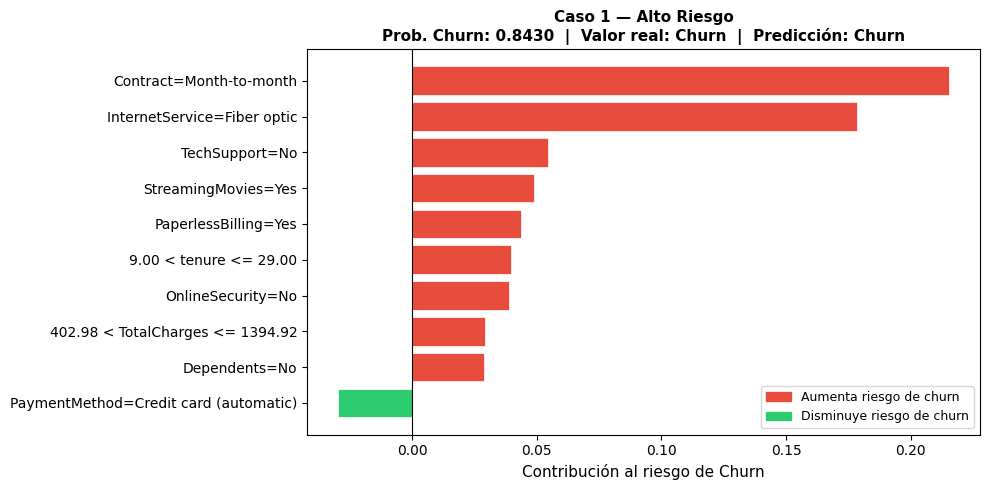

In [11]:
exp_alto = explain_and_plot('Caso 1 — Alto Riesgo', idx_alto)

**Interpretación — Caso 1 (Alto Riesgo):**

Este cliente presenta el perfil clásico de abandono identificado en el EDA:
- **Contract = Month-to-month**: sin compromiso de permanencia, la variable más influyente en la predicción de churn. LIME le asigna el mayor peso positivo (pro-churn).
- **tenure bajo** (≤ 12 meses): clientes nuevos tienen mayor probabilidad de abandono; aún no han generado lealtad.
- **MonthlyCharges alto**: cargo mensual elevado combinado con poca antigüedad aumenta la insatisfacción percibida.
- **PaymentMethod = Electronic check**: método de pago asociado estadísticamente a mayor churn, posiblemente por facilidad de cancelación.
- **Ausencia de OnlineSecurity / TechSupport**: servicios de valor añadido cuya ausencia aumenta la sensación de baja fidelización al servicio.

El modelo acertó la predicción — este cliente era genuinamente de alto riesgo.

## 8. Caso 2 — Cliente de Bajo Riesgo

In [12]:
exp_bajo = explain_and_plot('Caso 2 — Bajo Riesgo', idx_bajo)

KeyError: 1

**Interpretación — Caso 2 (Bajo Riesgo):**

El perfil opuesto al caso anterior. LIME muestra que las features que **reducen** el riesgo dominan la predicción:
- **Contract = Two year**: el tipo de contrato más protector contra el churn (~3% de tasa histórica). Contribución negativa (verde) prominente.
- **tenure alto** (> 48 meses): clientes de larga data son mucho más leales; ya han superado las etapas críticas de abandono temprano.
- **Presencia de OnlineSecurity y TechSupport**: servicios de valor añadido que generan mayor engagement con la plataforma.
- **MonthlyCharges moderado**: relación calidad-precio percibida como aceptable dado el nivel de servicios contratados.

La combinación de contrato largo + alta antigüedad + servicios complementarios es el perfil de cliente más estable en telecomunicaciones.

## 9. Caso 3 — Cliente Ambiguo (zona de incertidumbre)

In [ ]:
exp_ambiguo = explain_and_plot('Caso 3 — Ambiguo', idx_ambiguo)

**Interpretación — Caso 3 (Ambiguo):**

Este caso es el más interesante desde la perspectiva de negocio. La probabilidad cercana a 0.5 indica que el modelo percibe señales contradictorias:
- Algunas features sugieren retención (e.g., tenure moderado, contrato de un año)
- Otras sugieren abandono (e.g., MonthlyCharges elevado, sin servicios de seguridad)

**Implicación práctica:** Este cliente debería ser **el objetivo prioritario** de campañas de retención proactiva. La empresa debería:
1. Ofrecerle un upgrade a contrato de dos años con incentivo de precio.
2. Incluir OnlineSecurity o TechSupport de forma gratuita por 3 meses.
3. Monitorear su comportamiento de uso en el siguiente mes.

LIME permite exactamente este nivel de accionabilidad: saber **qué features cambiar** para mover al cliente fuera de la zona de riesgo.

## 10. Análisis agregado: consistencia entre LIME y feature importances

Una señal de robustez del modelo es que las explicaciones locales de LIME sean consistentes con las importancias globales del Notebook 2.

In [ ]:
# Recopilar los pesos LIME de los tres casos para comparar
all_exps = [
    ('Alto Riesgo',  exp_alto),
    ('Bajo Riesgo',  exp_bajo),
    ('Ambiguo',      exp_ambiguo)
]

# Crear un DataFrame con los pesos absolutos de cada caso
records = []
for label, exp in all_exps:
    for feat, weight in exp.as_list(label=1):
        records.append({
            'Caso':    label,
            'Feature': feat,
            'Peso':    weight,
            'Abs':     abs(weight)
        })

lime_df = pd.DataFrame(records)

# Top features más frecuentes en los tres casos
# (features que aparecen en la explicación de al menos 2 casos)
freq = (lime_df.groupby('Feature')['Caso']
        .nunique()
        .sort_values(ascending=False)
        .head(10))

print('Features más consistentes entre los tres casos LIME:')
print(freq.to_string())

In [ ]:
# Visualización: heatmap de contribuciones LIME por caso
# Solo features que aparecen en al menos 1 caso
pivot = (lime_df
         .pivot_table(index='Feature', columns='Caso', values='Peso', aggfunc='mean')
         .fillna(0))

# Ordenar por importancia absoluta media
pivot['abs_mean'] = pivot.abs().mean(axis=1)
pivot = pivot.sort_values('abs_mean', ascending=False).drop(columns='abs_mean').head(12)

fig, ax = plt.subplots(figsize=(9, 7))
import seaborn as sns
sns.heatmap(
    pivot,
    cmap='RdYlGn_r',
    center=0,
    annot=True,
    fmt='.3f',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Contribución al riesgo de churn'}
)
ax.set_title('Contribuciones LIME por caso y feature\n(rojo = aumenta churn, verde = reduce churn)',
             fontsize=12)
ax.set_ylabel('')
ax.set_xlabel('')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('data/lime_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

**Interpretación del heatmap:**

El heatmap consolida las explicaciones LIME de los tres casos. Se puede observar:
- `Contract` y `tenure` son las features con mayor variación de contribución entre casos, lo que confirma que son los drivers principales del modelo — consistente con las feature importances globales del Notebook 2.
- Para el Cliente de Alto Riesgo, `Contract` contribuye positivamente al churn (rojo); para el Bajo Riesgo, la dirección es opuesta (verde).
- La coherencia entre las explicaciones locales (LIME) y las globales (feature_importances_) es un indicador de que el modelo captura patrones reales y no artefactos espurios.

## 11. Exportación de explicaciones en formato tabular

In [ ]:
# Exportar tabla de explicaciones LIME para cada caso
output_rows = []
for label, idx in cases.items():
    prob = probs[idx]
    real = 'Churn' if y_test.values[idx] == 1 else 'No Churn'
    pred = 'Churn' if prob >= 0.5 else 'No Churn'
    exp_map = {'Alto Riesgo': exp_alto, 'Bajo Riesgo': exp_bajo, 'Ambiguo': exp_ambiguo}
    key = [k for k in exp_map if k in label][0]
    for feat, weight in exp_map[key].as_list(label=1):
        output_rows.append({
            'Caso':         label,
            'Prob_Churn':   round(prob, 4),
            'Real':         real,
            'Prediccion':   pred,
            'Feature':      feat,
            'Contribucion': round(weight, 4),
            'Direccion':    'Pro-churn' if weight > 0 else 'Anti-churn'
        })

lime_export = pd.DataFrame(output_rows)
lime_export.to_csv('data/lime_explanations.csv', index=False)

print('Exportado: data/lime_explanations.csv')
lime_export.head(15)

## 12. Conclusiones de Interpretabilidad

| Aspecto | Hallazgo |
|---|---|
| Feature más influyente | `Contract` — determina la dirección de la predicción en todos los casos |
| Segunda feature clave | `tenure` — complementa el efecto del tipo de contrato |
| Consistencia global/local | Alta — las explicaciones LIME son coherentes con `feature_importances_` del Notebook 2 |
| Accionabilidad | Los clientes ambiguos son el target ideal para campañas de retención basadas en las features identificadas por LIME |
| Confianza del modelo | Alta en extremos (alto/bajo riesgo); moderada en zona ambigua — apropiado para un sistema de alertas escalonado |

**Recomendación de negocio:** Implementar tres niveles de intervención basados en la probabilidad de churn:
- **> 0.70**: intervención inmediata con oferta personalizada
- **0.40 – 0.70**: monitoreo activo y campaña de engagement
- **< 0.40**: seguimiento rutinario sin acción urgente

LIME permite que el equipo de retención comprenda **por qué** el modelo marcó a un cliente, generando confianza en el sistema y mejorando la calidad de las intervenciones.